In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("Supervised_Learning_Messy_Customer_Churn.csv")
df.shape

(184, 13)

In [ ]:
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    object 
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    object 
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    object 
 9   Payment_Method         184 non-null    object 
 10  Region                 184 non-null    object 
 11  Plan_Type              184 non-null    object 
 12  Churn                  184 non-null    object 
dtypes: float64(6), object(7)
memory usage: 18.8+ KB


In [ ]:
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

In [ ]:
df['Annual_Income'].dtype

dtype('float64')

In [ ]:
df.describe()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,1.720000e+02,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,1.218552e+05,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,7.579821e+05,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,-1.200000e+04,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,4.860000e+04,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,6.440000e+04,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,7.797500e+04,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,9.999999e+06,150.000000,999.000000,30.000000,44.000000,15.000000


In [ ]:
df["Churn"].value_counts()

Churn
Yes    97
No     87
Name: count, dtype: int64

In [ ]:
df["Customer_ID"].value_counts()

Customer_ID
CUST-1043    2
CUST-1110    2
CUST-1008    2
CUST-1152    2
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-1103    1
Name: count, Length: 180, dtype: int64

In [ ]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

In [ ]:
df.isnull().sum().sum()

np.int64(50)

In [ ]:
df.duplicated().sum()

np.int64(4)

In [ ]:
df['Customer_ID'].duplicated().sum()

np.int64(4)

In [ ]:
df[df.duplicated(keep=False)].sort_values('Customer_ID').head(10)

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [ ]:
numeric_cols = ['Age','Annual_Income','Tenure_Months','Monthly_Charges',
                'Support_Calls_Last_3M','Data_Usage_GB','Satisfaction_Score']

In [ ]:
num_cols = df.select_dtypes(exclude=['object']).columns
print(num_cols)

Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score'],
      dtype='object')


In [ ]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type',
       'Churn'],
      dtype='object')


In [ ]:
df["Contract_Type"].value_counts()

Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

In [ ]:
df['Contract_Type'] = df['Contract_Type'].replace('?', pd.NA)

df['Contract_Type'] = (
    df['Contract_Type']
    .str.strip()
    .str.lower()
    .replace({
        'monthly': 'Monthly',
        '1 year': '1 Year',
        '2 year': '2 Year',
        '2-year': '2 Year'
    })
)
df["Contract_Type"].value_counts()

Contract_Type
Monthly    106
1 Year      53
2 Year      24
Name: count, dtype: int64

In [ ]:
df['Contract_Type'] = df['Contract_Type'].fillna(df['Contract_Type'].mode()[0])

In [ ]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

In [ ]:
df["Payment_Method"] = df["Payment_Method"].str.strip().str.title()
df["Payment_Method"].value_counts()


Payment_Method
Bank Transfer    49
Upi              47
Credit Card      44
Debit Card       42
?                 1
Unknown           1
Name: count, dtype: int64

In [ ]:
df["Payment_Method"] = df["Payment_Method"].replace("?", np.nan)

In [ ]:
df["Payment_Method"] = df["Payment_Method"].fillna(df["Payment_Method"].mode()[0])

In [ ]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    50
Upi              47
Credit Card      44
Debit Card       42
Unknown           1
Name: count, dtype: int64

In [ ]:
df["Region"].value_counts()

Region
South     50
North     49
West      47
East      34
west       1
NORTH      1
?          1
south      1
Name: count, dtype: int64

In [ ]:
df["Region"] = df["Region"].str.strip().str.title()
df["Region"].value_counts()

Region
South    51
North    50
West     48
East     34
?         1
Name: count, dtype: int64

In [ ]:
df["Region"] = df["Region"].replace("?", np.nan)

In [ ]:
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

In [ ]:
df["Region"].value_counts()

Region
South    52
North    50
West     48
East     34
Name: count, dtype: int64

In [ ]:
df["Plan_Type"].value_counts()

Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

In [ ]:
df["Plan_Type"] = df["Plan_Type"].str.strip().str.title()
df["Plan_Type"].value_counts()

Plan_Type
Standard    94
Basic       49
Premium     41
Name: count, dtype: int64

In [ ]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      1
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            7
Satisfaction_Score       0
dtype: int64


In [ ]:
numeric_cols = df.select_dtypes(include="number")
negative_rows = df[(numeric_cols < 0).any(axis=1)]
negative_rows

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
45,CUST-1105,34.0,35800.0,60.0,118.63,3.0,-0.8,7.0,2 Year,Upi,East,Standard,No
63,CUST-1079,NaN,53100.0,29.0,83.71,3.0,-1.6,5.0,Monthly,Upi,North,Basic,Yes
77,CUST-1033,36.0,57800.0,72.0,50.61,3.0,-1.1,1.0,Monthly,Credit Card,North,Standard,Yes
95,CUST-1143,20.0,-11500.0,2.0,57.34,NaN,19.4,2.0,1 Year,Credit Card,West,Standard,No
112,CUST-1062,34.0,-12000.0,29.0,60.69,4.0,18.9,4.0,Monthly,Upi,East,Basic,Yes
120,CUST-1124,22.0,50100.0,57.0,93.56,3.0,-0.3,9.0,Monthly,Upi,South,Standard,No
144,CUST-1018,-5.0,75900.0,64.0,137.15,5.0,14.2,5.0,Monthly,Upi,North,Premium,Yes
177,CUST-1021,51.0,100400.0,14.0,51.52,2.0,-2.0,1.0,2 Year,Upi,South,Premium,No
178,CUST-1072,51.0,NaN,38.0,77.19,5.0,-10.0,5.0,Monthly,Credit Card,West,Standard,No


In [ ]:
df["Age"] = df["Age"].mask(df["Age"] < 0, np.nan)
df["Data_Usage_GB"] = df["Data_Usage_GB"].mask(
    df["Data_Usage_GB"] < 0, np.nan
)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Data_Usage_GB"] = df["Data_Usage_GB"].fillna(
    df["Data_Usage_GB"].median()
)

In [ ]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      0
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [ ]:
median_income = df.loc[df['Annual_Income'] >= 0, 'Annual_Income'].median()
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = median_income
print("Negative values:", (df['Annual_Income'] < 0).sum())
print("Median used:", median_income)

Negative values: 0
Median used: 64700.0


In [ ]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()
correlation

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.005074,0.032331,0.005018,-0.021513,-0.029712,-0.051955
Annual_Income,0.005074,1.000000,-0.127055,0.011238,0.025034,-0.120125,0.087546
Tenure_Months,0.032331,-0.127055,1.000000,-0.006854,-0.040394,0.034958,0.005583
Monthly_Charges,0.005018,0.011238,-0.006854,1.000000,0.021635,0.001403,0.105330
Support_Calls_Last_3M,-0.021513,0.025034,-0.040394,0.021635,1.000000,-0.036642,-0.031787
Data_Usage_GB,-0.029712,-0.120125,0.034958,0.001403,-0.036642,1.000000,0.042551
Satisfaction_Score,-0.051955,0.087546,0.005583,0.105330,-0.031787,0.042551,1.000000


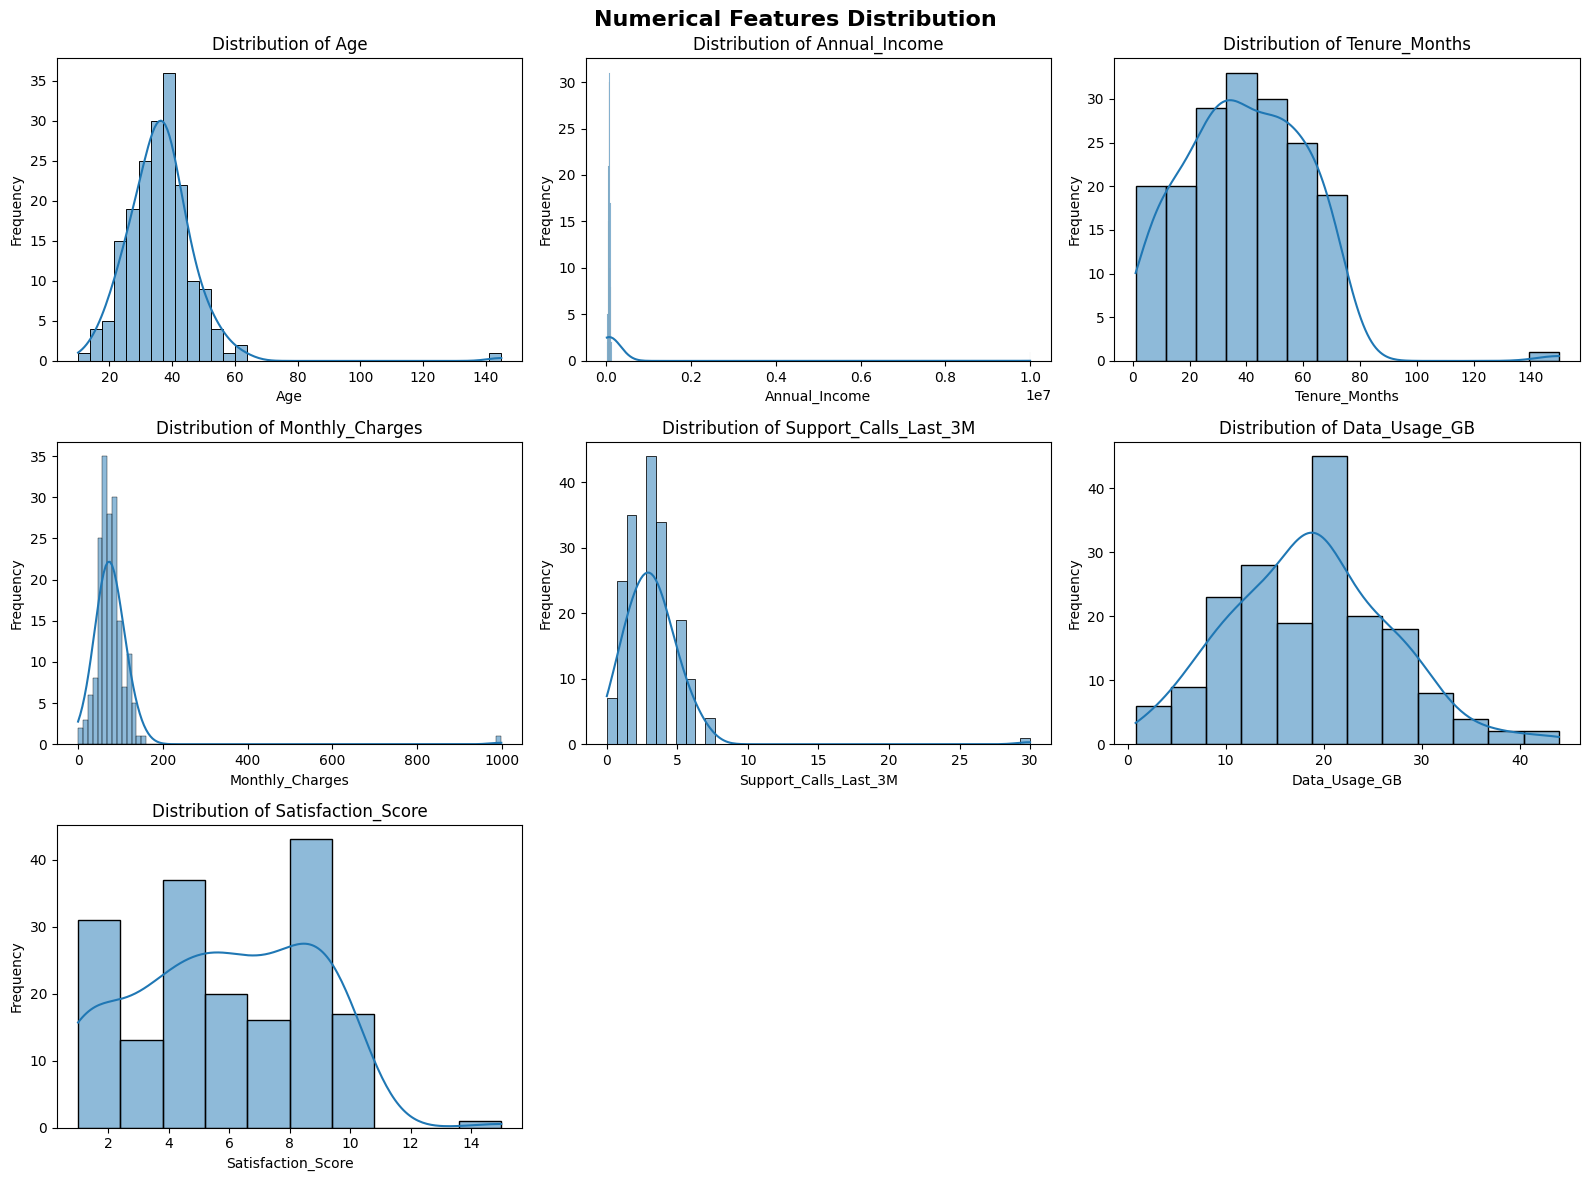

In [ ]:
numeric_cols = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    "Numerical Features Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

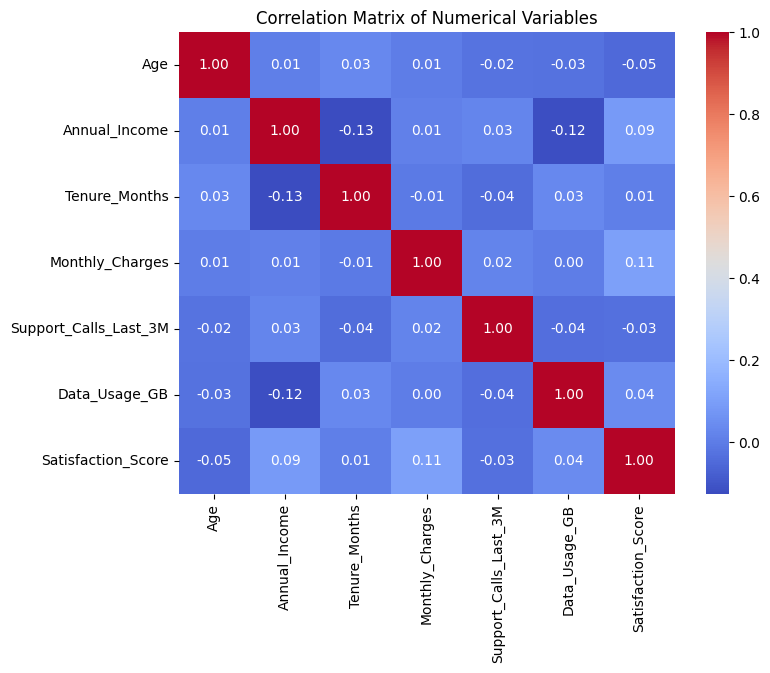

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include="number")
for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}")
    print(f"Lower limit: {lower}")
    print(f"Upper limit: {upper}")
    print(f"Number of outliers: {len(outliers)}")


Age
Lower limit: 13.5
Upper limit: 57.5
Number of outliers: 5

Annual_Income
Lower limit: 6912.5
Upper limit: 120612.5
Number of outliers: 2

Tenure_Months
Lower limit: -20.0
Upper limit: 100.0
Number of outliers: 1

Monthly_Charges
Lower limit: 9.292500000000011
Upper limit: 138.8725
Number of outliers: 4

Support_Calls_Last_3M
Lower limit: -1.0
Upper limit: 7.0
Number of outliers: 1

Data_Usage_GB
Lower limit: -3.3125000000000036
Upper limit: 40.587500000000006
Number of outliers: 2

Satisfaction_Score
Lower limit: -2.0
Upper limit: 14.0
Number of outliers: 1


In [ ]:
numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    percentage = (outlier_count / len(df)) * 100
    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")

Age: 5 outliers (2.72%)
Annual_Income: 2 outliers (1.09%)
Tenure_Months: 1 outliers (0.54%)
Monthly_Charges: 4 outliers (2.17%)
Support_Calls_Last_3M: 1 outliers (0.54%)
Data_Usage_GB: 2 outliers (1.09%)
Satisfaction_Score: 1 outliers (0.54%)


In [ ]:
numeric_cols = df.select_dtypes(include="number").columns
total_outliers = 0
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    total_outliers += ((df[col] < lower) | (df[col] > upper)).sum()
print("Total outliers:", total_outliers)

Total outliers: 16


In [ ]:
total_values = len(df) * len(numeric_cols)
percentage = (total_outliers / total_values) * 100
print(f"Total outliers: {total_outliers}")
print(f"Outlier percentage: {percentage:.2f}%")

Total outliers: 16
Outlier percentage: 1.24%


In [ ]:

numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

# Replace invalid values with NaN
df['Age'] = df['Age'].replace([10, 16, 17, 145], pd.NA)

df['Annual_Income'] = df['Annual_Income'].replace([9999999], pd.NA)

df['Tenure_Months'] = df['Tenure_Months'].replace([150], pd.NA)

df['Monthly_Charges'] = df['Monthly_Charges'].replace([0, 999], pd.NA)

df['Support_Calls_Last_3M'] = df['Support_Calls_Last_3M'].replace([30], pd.NA)

df['Satisfaction_Score'] = df['Satisfaction_Score'].replace([15], pd.NA)

# Convert to numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace invalid/missing values with column median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fix capitalization
if 'Payment_Method' in df.columns:
    df['Payment_Method'] = df['Payment_Method'].replace({
        'Upi': 'UPI'
    })

print(df.head())

  Customer_ID   Age  Annual_Income  Tenure_Months  Monthly_Charges  \
0   CUST-1020  22.0        23800.0           11.0            62.96   
1   CUST-1043  35.0        69400.0           17.0            75.63   
2   CUST-1157  55.0        64700.0           49.0            92.85   
3   CUST-1112  36.0        80000.0            9.0            85.67   
4   CUST-1149  41.0        95700.0           51.0            60.77   

   Support_Calls_Last_3M  Data_Usage_GB  Satisfaction_Score Contract_Type  \
0                    7.0           20.4                 5.0       Monthly   
1                    6.0           17.5                 9.0       Monthly   
2                    3.0           21.6                 1.0       Monthly   
3                    0.0           34.3                 9.0       Monthly   
4                    1.0           23.7                 9.0       Monthly   

  Payment_Method Region Plan_Type Churn  
0  Bank Transfer  North  Standard   Yes  
1  Bank Transfer  South     Basi

In [ ]:
numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

total_outliers = 0
total_values = 0

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    outlier_count = len(outliers)
    
    total_outliers += outlier_count
    total_values += df[col].count()
    
    print(f"{col}: {outlier_count} outliers")


outlier_percentage = (total_outliers / total_values) * 100

print("\nTotal Outlier Values:", total_outliers)
print("Total Numerical Values:", total_values)
print(f"Overall Outlier Percentage: {outlier_percentage:.2f}%")

Age: 3 outliers
Annual_Income: 3 outliers
Tenure_Months: 0 outliers
Monthly_Charges: 8 outliers
Support_Calls_Last_3M: 0 outliers
Data_Usage_GB: 2 outliers
Satisfaction_Score: 0 outliers

Total Outlier Values: 16
Total Numerical Values: 1288
Overall Outlier Percentage: 1.24%


In [ ]:
df.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(180, 13)

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns
print(df[numeric_cols].median())

Age                         36.000
Annual_Income            64700.000
Tenure_Months               38.000
Monthly_Charges             73.565
Support_Calls_Last_3M        3.000
Data_Usage_GB               18.800
Satisfaction_Score           6.000
dtype: float64


In [ ]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
print(df[numeric_cols].isnull().sum())
print(df[numeric_cols].dtypes)

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
dtype: object


In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. BASIC DATASET INFORMATION
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Rows and Columns:", df.shape)
print("\nData Types:")
print(df.dtypes)


# ==========================================
# 2. NULL VALUES
# ==========================================

print("\n" + "=" * 60)
print("NULL VALUES")
print("=" * 60)

null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if len(null_counts) == 0:
    print("No null values found.")
else:
    print(null_counts)
    print("\nTotal null values:", df.isnull().sum().sum())


# ==========================================
# 3. DUPLICATE DATA
# ==========================================

print("\n" + "=" * 60)
print("DUPLICATE DATA")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)])

# ==========================================
# 5. INVALID / NON-NUMERIC DATA
# ==========================================

print("\n" + "=" * 60)
print("INVALID / NON-NUMERIC DATA")
print("=" * 60)

for col in numeric_cols:
    invalid = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    
    if invalid.sum() > 0:
        print(f"\n{col}: {invalid.sum()} invalid values")
        print(df.loc[invalid, col].unique())

print("\nObject/Categorical columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].isna().sum()} null values")


# ==========================================
# 6. VALUE COUNT OF CATEGORICAL DATA
# ==========================================

print("\n" + "=" * 60)
print("CATEGORICAL VALUE COUNTS")
print("=" * 60)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


# ==========================================
# 7. SUMMARY
# ==========================================

print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Total Null Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

DATASET INFORMATION
Rows and Columns: (180, 13)

Data Types:
Customer_ID               object
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object

NULL VALUES
No null values found.

DUPLICATE DATA
Duplicate rows: 0

INVALID / NON-NUMERIC DATA

Object/Categorical columns:
Customer_ID: 0 null values
Contract_Type: 0 null values
Payment_Method: 0 null values
Region: 0 null values
Plan_Type: 0 null values
Churn: 0 null values

CATEGORICAL VALUE COUNTS

--- Customer_ID ---
Customer_ID
CUST-1020    1
CUST-1043    1
CUST-1157    1
CUST-1112    1
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-11

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", len(categorical_cols))
print(categorical_cols.tolist())

Categorical Columns: 6
['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [ ]:
cols = ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']
for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Contract_Type ---
Contract_Type
Monthly    104
1 Year      52
2 Year      24
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
Bank Transfer    47
UPI              47
Credit Card      44
Debit Card       41
Unknown           1
Name: count, dtype: int64

--- Region ---
Region
North    50
South    50
West     46
East     34
Name: count, dtype: int64

--- Plan_Type ---
Plan_Type
Standard    94
Basic       47
Premium     39
Name: count, dtype: int64


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
negative_counts = {}
for col in numeric_cols:
    count = (df[col] < 0).sum()
    if count > 0:
        negative_counts[col] = count

if len(negative_counts) == 0:
    print("No negative values found.")
else:
    print("Negative values by column:")
    for col, count in negative_counts.items():
        print(f"{col}: {count}")

No negative values found.


In [ ]:
clean_df = df.copy()

In [ ]:
print(clean_df.shape)
print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())

(180, 13)
Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64
0


In [ ]:
print((clean_df.select_dtypes(include='number') < 0).sum())

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [ ]:
clean_df.to_csv("cleaned_customer1.csv", index=False)

### Data preprocessing(unsupervised)

In [ ]:
df_cluster = df.drop(columns=["Churn", "Customer_ID"])
df_cluster.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium


In [ ]:
numeric_columns = df_cluster.select_dtypes(include=["int", "float"]).columns.tolist()
categorical_columns = df_cluster.select_dtypes(include=["object"]).columns.tolist()
numeric_columns

['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

In [ ]:
correlation = df[numeric_columns].corr()

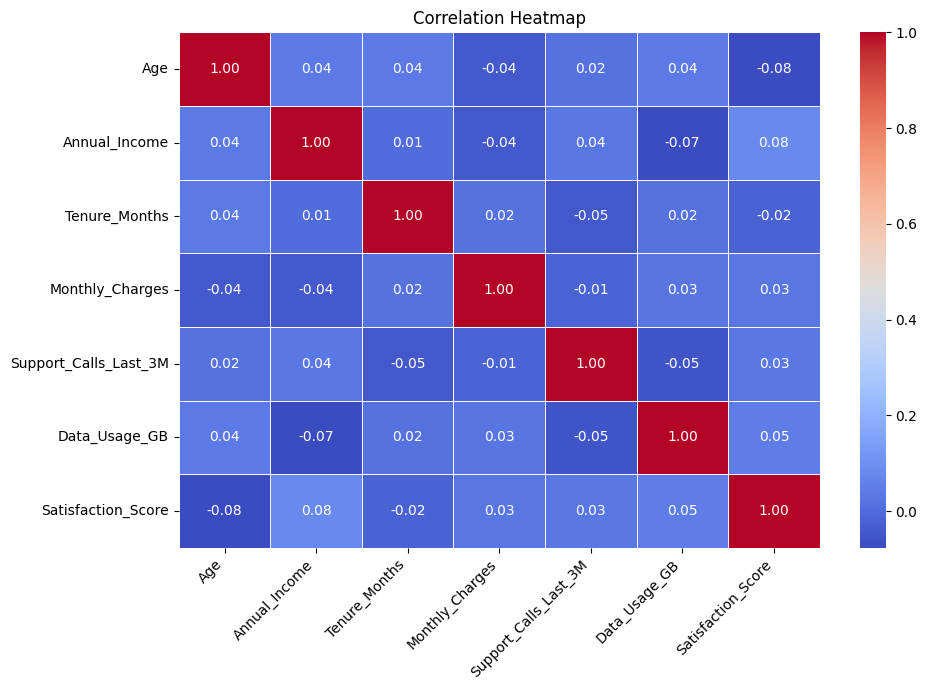

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

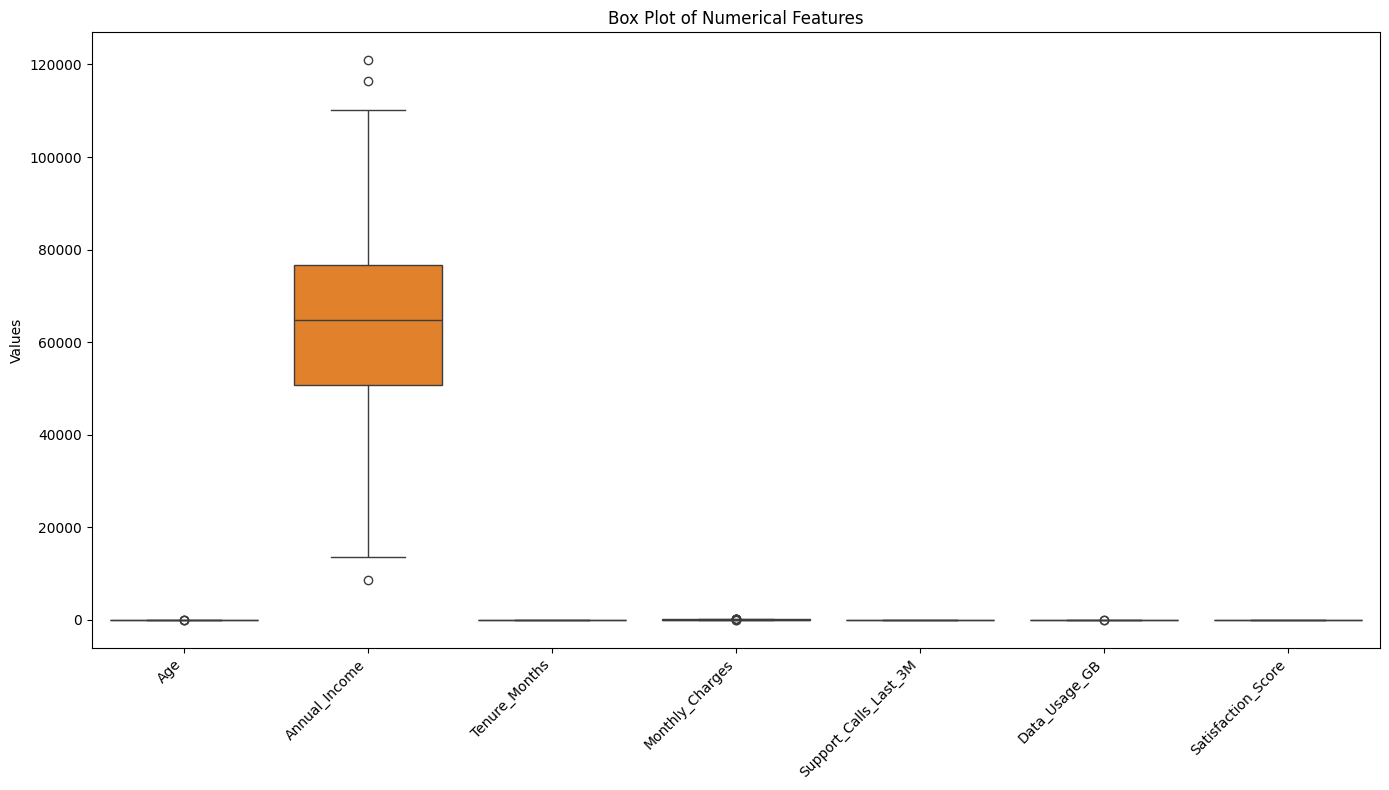

In [ ]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numeric_columns])
plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [ ]:
df_cluster[numeric_columns] = df_cluster[numeric_columns].fillna(
    df_cluster[numeric_columns].median()
)

for column in categorical_columns:
    df_cluster[column] = df_cluster[column].fillna(
        df_cluster[column].mode()[0]
    )
df_cluster.isnull().sum()

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
dtype: int64

### Convert Categorical Features to Numerical Features

Clustering algorithms require numerical input, so categorical variables are converted using one-hot encoding.

In [ ]:
df_encoded = pd.get_dummies(
    df_cluster,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)
df_encoded

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,...,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,0,0,1,...,0,1,0,0,0,1,0,0,0,1
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,0,0,1,...,1,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
180,19.0,63000.0,38.0,64.24,1.0,13.0,7.0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
181,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,0,0,1,...,1,0,0,1,0,0,0,0,0,1
182,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,0,0,1,...,0,1,0,1,0,0,0,0,0,1


In [ ]:
df_encoded.shape

(180, 22)

### Select Features for Clustering

In [ ]:
X = df_encoded.copy()
X.shape

(180, 22)

In [ ]:
X.columns

Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score',
       'Contract_Type_1 Year', 'Contract_Type_2 Year', 'Contract_Type_Monthly',
       'Payment_Method_Bank Transfer', 'Payment_Method_Credit Card',
       'Payment_Method_Debit Card', 'Payment_Method_UPI',
       'Payment_Method_Unknown', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Plan_Type_Basic', 'Plan_Type_Premium',
       'Plan_Type_Standard'],
      dtype='object')

### Feature Scaling(MinMax)

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.08888889, 0.13535174, 0.14084507, ..., 0.        , 0.        ,
        1.        ],
       [0.37777778, 0.54140695, 0.22535211, ..., 1.        , 0.        ,
        0.        ],
       [0.82222222, 0.49955476, 0.67605634, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.24444444, 0.32680321, 0.95774648, ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.3428317 , 0.61971831, ..., 0.        , 0.        ,
        1.        ],
       [0.4       , 0.35351736, 0.16901408, ..., 0.        , 0.        ,
        1.        ]])

In [ ]:
k_values = range(2, 9)

inertia_values = []
silhouette_values = []

In [ ]:
for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    

    inertia_values.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_values.append(silhouette_avg)

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File

In [ ]:
results = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia_values,
    'Silhouette_Score': silhouette_values
})
results

,K,Inertia,Silhouette_Score
0,2,476.024504,0.131124
1,3,431.316727,0.126978
2,4,392.830988,0.141246
3,5,378.580949,0.115168
4,6,362.676502,0.111441
5,7,343.095530,0.140124
6,8,332.955644,0.129791


In [ ]:
best_k = results.loc[
    results['Silhouette_Score'].idxmax(),
    'K'
]
best_silhouette = results['Silhouette_Score'].max()
print("Best K based on Silhouette Score:", best_k)
print("Highest Silhouette Score:", best_silhouette)

Best K based on Silhouette Score: 4
Highest Silhouette Score: 0.14124633564114097


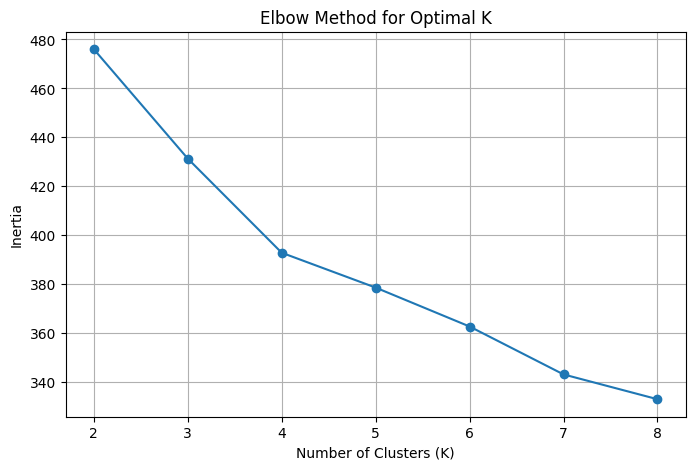

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.xticks(k_values)
plt.grid(True)

plt.show()

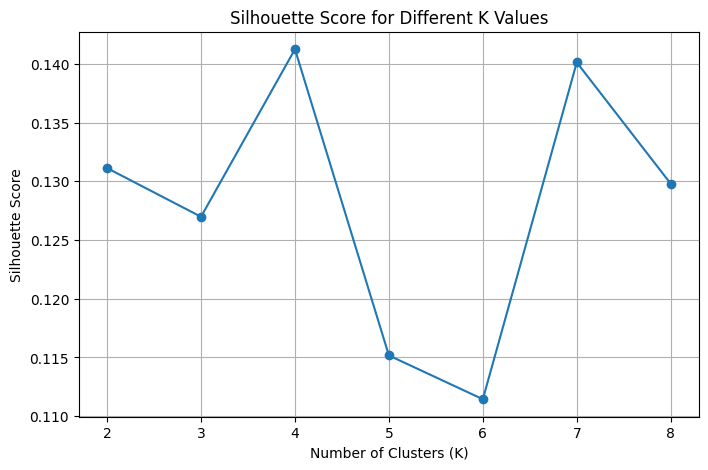

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')

plt.xticks(k_values)
plt.grid(True)

plt.show()

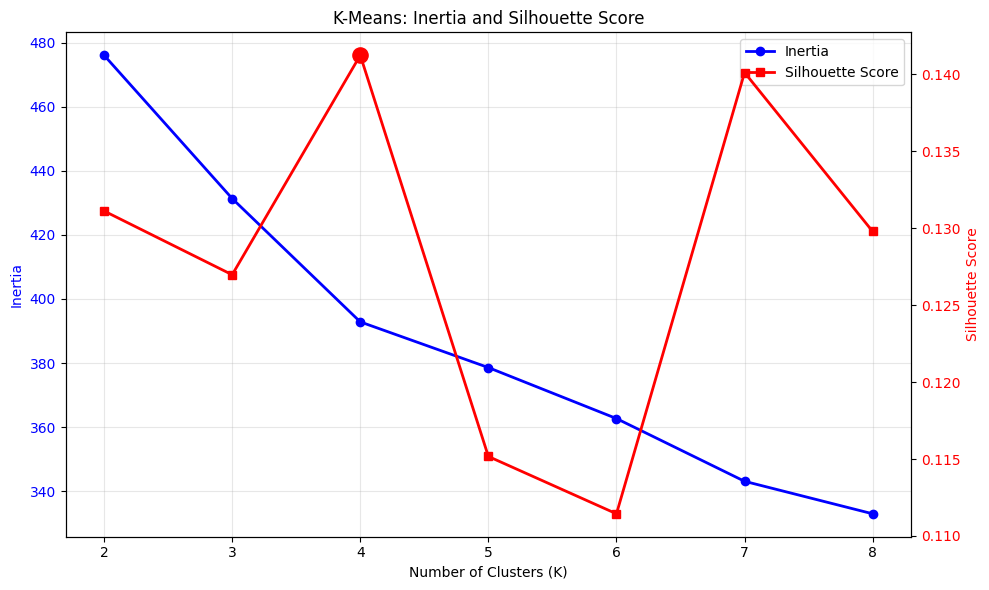

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))


line1 = ax1.plot(
    results['K'],
    results['Inertia'],
    marker='o',
    linewidth=2,
    color='blue',
    label='Inertia'
)

ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(results['K'])
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

line2 = ax2.plot(
    results['K'],
    results['Silhouette_Score'],
    marker='s',
    linewidth=2,
    color='red',
    label='Silhouette Score'
)

ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')


best_k = results.loc[
    results['Silhouette_Score'].idxmax(),
    'K'
]

best_score = results['Silhouette_Score'].max()

# Mark best K
ax2.scatter(
    best_k,
    best_score,
    color='red',
    s=120,
    zorder=5
)

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc='upper right'
)

plt.title('K-Means: Inertia and Silhouette Score')

plt.tight_layout()
plt.show()

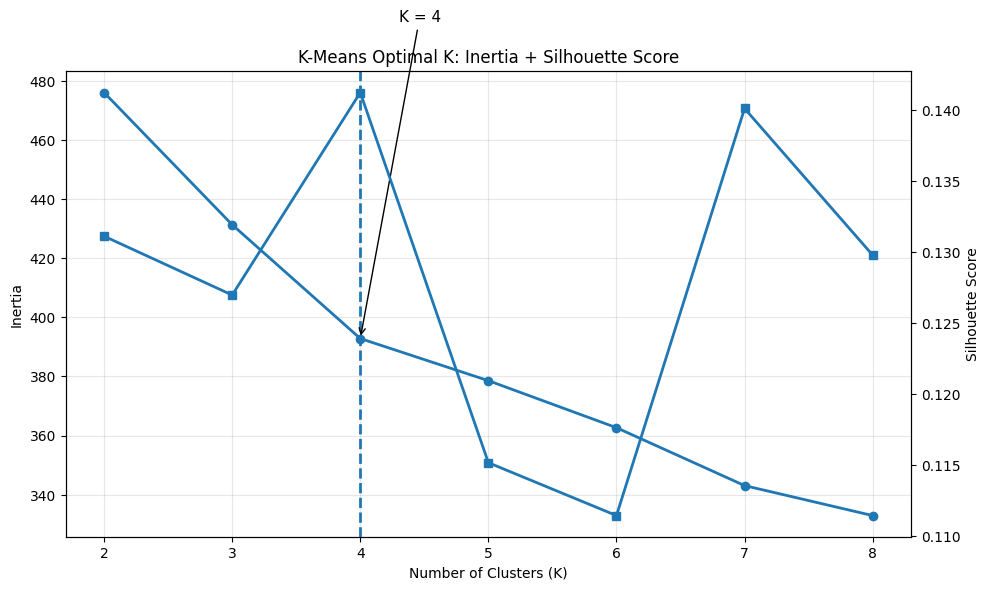

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    results['K'],
    results['Inertia'],
    marker='o',
    linewidth=2,
    label='Inertia'
)

ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(results['K'])
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    results['K'],
    results['Silhouette_Score'],
    marker='s',
    linewidth=2,
    label='Silhouette Score'
)

ax2.set_ylabel('Silhouette Score')

# Mark K = 3
selected_k = 4

ax1.axvline(
    x=selected_k,
    linestyle='--',
    linewidth=2
)

ax1.annotate(
    'K = 4',
    xy=(selected_k, results.loc[
        results['K'] == selected_k, 'Inertia'
    ].iloc[0]),
    xytext=(selected_k + 0.3, 500),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

plt.title('K-Means Optimal K: Inertia + Silhouette Score')

plt.tight_layout()
plt.show()

- K=4 was selected because it produced the highest silhouette score 0.141, among the evaluated cluster counts, while the inertia showed the expected decreasing 392.

## K-MEAN

In [ ]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

final_clusters = final_kmeans.fit_predict(X_scaled)

In [ ]:
final_kmeans.labels_

array([0, 1, 1, 0, 2, 3, 3, 1, 2, 1, 0, 2, 1, 3, 0, 0, 2, 3, 0, 3, 3, 2,
       1, 3, 0, 2, 1, 1, 1, 3, 3, 3, 1, 2, 3, 3, 1, 2, 0, 2, 3, 0, 2, 2,
       0, 3, 2, 1, 0, 0, 3, 1, 0, 1, 2, 1, 3, 1, 2, 1, 0, 2, 1, 1, 0, 0,
       1, 0, 1, 3, 2, 2, 0, 1, 1, 0, 0, 2, 3, 2, 1, 0, 0, 3, 2, 0, 1, 0,
       2, 2, 2, 1, 1, 1, 3, 2, 0, 3, 0, 1, 0, 1, 3, 1, 0, 3, 2, 0, 0, 3,
       3, 1, 3, 0, 3, 2, 0, 2, 0, 3, 3, 0, 2, 0, 1, 2, 2, 2, 0, 1, 1, 0,
       3, 1, 2, 1, 3, 3, 0, 0, 2, 1, 2, 3, 1, 0, 2, 1, 3, 1, 3, 1, 0, 3,
       3, 0, 0, 0, 0, 1, 0, 1, 3, 1, 3, 1, 2, 0, 0, 3, 3, 0, 2, 2, 0, 1,
       2, 0, 0, 3], dtype=int32)

In [ ]:
df["Label"] = final_kmeans.labels_

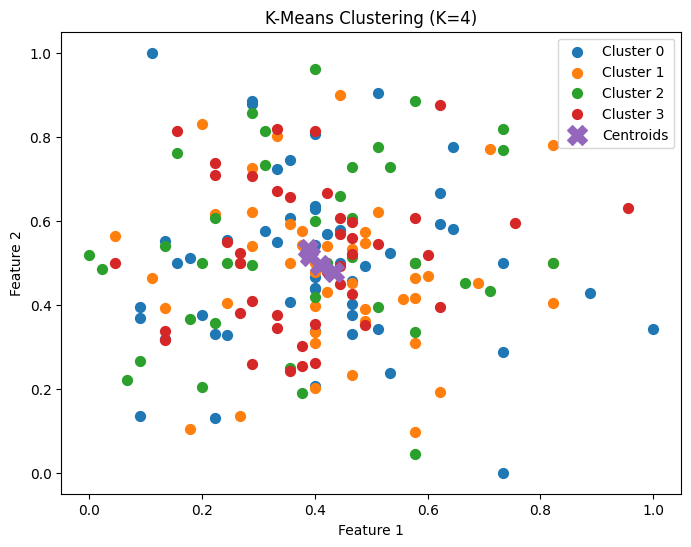

In [ ]:
plt.figure(figsize=(8,6))

for cluster in range(best_k):
    plt.scatter(
        X_scaled[final_clusters == cluster, 0],
        X_scaled[final_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        s=50
    )

plt.scatter(
    final_kmeans.cluster_centers_[:, 0],
    final_kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'K-Means Clustering (K={best_k})')
plt.legend()
plt.show()

### overlapping

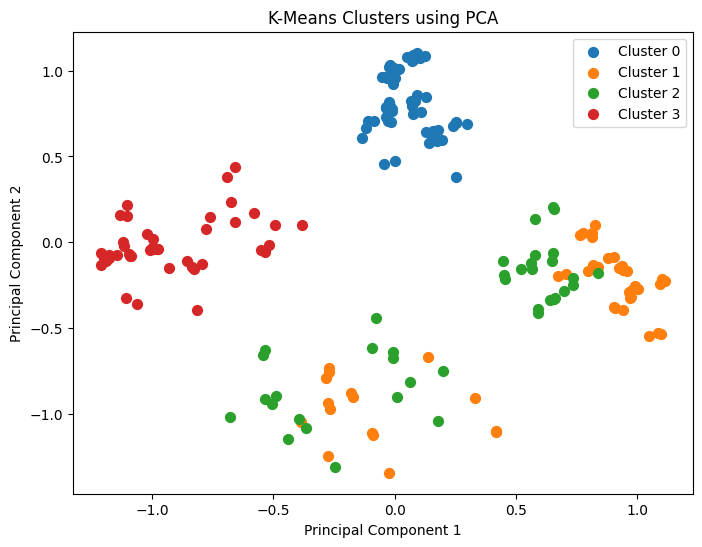

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for cluster in range(best_k):
    plt.scatter(
        X_pca[final_clusters == cluster, 0],
        X_pca[final_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        s=50
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters using PCA')
plt.legend()
plt.show()

In [ ]:
df_cluster = df.copy()

df_cluster['Cluster'] = final_clusters

df_cluster.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,Label,Cluster
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes,0,0
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes,1,1
2,CUST-1157,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes,1,1
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes,0,0
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes,2,2


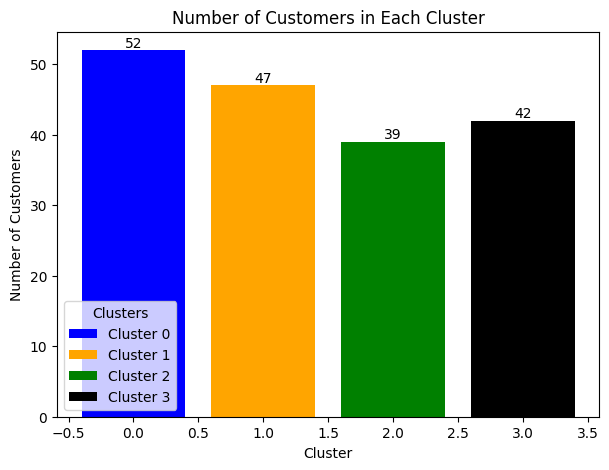

In [ ]:
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    cluster_counts.index,
    cluster_counts.values,
    color=['blue', 'orange', 'green','black']
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')

# Add legend
plt.legend(
    bars,
    [f'Cluster {cluster}' for cluster in cluster_counts.index],
    title='Clusters'
)

# Add values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
final_silhouette = silhouette_score(
    X_scaled,
    final_clusters
)

print("Selected K:", best_k)
print("Final Silhouette Score:", final_silhouette)
print("Final Inertia:", final_kmeans.inertia_)

Selected K: 4
Final Silhouette Score: 0.14124633564114097
Final Inertia: 392.83098801412314


In [ ]:
df_cluster["Cluster"].value_counts()

Cluster
0    52
1    47
3    42
2    39
Name: count, dtype: int64

In [ ]:
df_cluster["Cluster"].value_counts().sort_index()

Cluster
0    52
1    47
2    39
3    42
Name: count, dtype: int64

In [ ]:
numeric_cols = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

In [ ]:
cluster_profile = df_cluster.groupby("Cluster")[numeric_cols].mean()
cluster_profile.round(2)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Cluster,,,,,,,
0,36.42,64203.85,40.73,68.21,3.19,19.39,6.15
1,37.55,62287.23,37.91,76.06,3.11,20.88,5.04
2,35.41,68425.64,38.87,80.78,2.87,15.85,6.05
3,35.62,66647.62,36.60,76.61,3.00,17.92,5.81


In [ ]:
overall_mean = df_cluster[numeric_cols].mean()

cluster_vs_overall = cluster_profile - overall_mean

cluster_vs_overall.round(2)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Cluster,,,,,,,
0,0.11,-984.49,2.10,-6.73,0.14,0.72,0.39
1,1.24,-2901.10,-0.71,1.12,0.05,2.21,-0.72
2,-0.90,3237.31,0.24,5.83,-0.18,-2.82,0.29
3,-0.69,1459.29,-2.03,1.67,-0.06,-0.75,0.05


In [ ]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Contract_Type"],
    normalize="index"
).round(2) * 100

Contract_Type,1 Year,2 Year,Monthly
Cluster,,,
0,0.0,0.0,100.0
1,26.0,9.0,66.0
2,26.0,21.0,54.0
3,71.0,29.0,0.0


In [ ]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Plan_Type"],
    normalize="index"
).round(2) * 100

Plan_Type,Basic,Premium,Standard
Cluster,,,
0,0.0,0.0,100.0
1,100.0,0.0,0.0
2,0.0,100.0,0.0
3,0.0,0.0,100.0


In [ ]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Payment_Method"],
    normalize="index"
).round(2) * 100

Payment_Method,Bank Transfer,Credit Card,Debit Card,UPI,Unknown
Cluster,,,,,
0,27.0,33.0,10.0,29.0,2.0
1,30.0,19.0,30.0,21.0,0.0
2,21.0,26.0,28.0,26.0,0.0
3,26.0,19.0,26.0,29.0,0.0


In [ ]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Churn"],
    normalize="index"
).round(2) * 100

Churn,No,Yes
Cluster,,
0,46.0,54.0
1,32.0,68.0
2,54.0,46.0
3,62.0,38.0


In [ ]:
cluster_names = {
    0: "Premium Light Users",
    1: "Moderate-Usage Support Customers",
    2: "High-Usage Customers",
    3:"best Users"
}

In [ ]:
df_cluster["Customer_Segment"] = df_cluster["Cluster"].map(cluster_names)

In [ ]:
df_cluster[["Cluster", "Customer_Segment"]].head(20)

,Cluster,Customer_Segment
0,0,Premium Light Users
1,1,Moderate-Usage Support Customers
2,1,Moderate-Usage Support Customers
3,0,Premium Light Users
4,2,High-Usage Customers
5,3,best Users
6,3,best Users
7,1,Moderate-Usage Support Customers
8,2,High-Usage Customers
9,1,Moderate-Usage Support Customers


In [ ]:
df_cluster["Customer_Segment"].value_counts()

Customer_Segment
Premium Light Users                 52
Moderate-Usage Support Customers    47
best Users                          42
High-Usage Customers                39
Name: count, dtype: int64

In [ ]:

print("=" * 60)
print("1. CUSTOMER COUNT BY SEGMENT")
print("=" * 60)
print(df_cluster["Customer_Segment"].value_counts())


# 2. Contract Type
print("\n" + "=" * 60)
print("2. CONTRACT TYPE BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Contract_Type"],
        normalize="index"
    ).round(2) * 100
)



# 4. Payment Method
print("\n" + "=" * 60)
print("4. PAYMENT METHOD BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Payment_Method"],
        normalize="index"
    ).round(2) * 100
)


# 5. Region
print("\n" + "=" * 60)
print("5. REGION BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Region"],
        normalize="index"
    ).round(2) * 100
)


# 6. Churn
print("\n" + "=" * 60)
print("6. CHURN BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Churn"],
        normalize="index"
    ).round(2) * 100
)

1. CUSTOMER COUNT BY SEGMENT
Customer_Segment
Premium Light Users                 52
Moderate-Usage Support Customers    47
best Users                          42
High-Usage Customers                39
Name: count, dtype: int64

2. CONTRACT TYPE BY SEGMENT (%)
Contract_Type                     1 Year  2 Year  Monthly
Customer_Segment                                         
High-Usage Customers                26.0    21.0     54.0
Moderate-Usage Support Customers    26.0     9.0     66.0
Premium Light Users                  0.0     0.0    100.0
best Users                          71.0    29.0      0.0

4. PAYMENT METHOD BY SEGMENT (%)
Payment_Method                    Bank Transfer  Credit Card  Debit Card  \
Customer_Segment                                                           
High-Usage Customers                       21.0         26.0        28.0   
Moderate-Usage Support Customers           30.0         19.0        30.0   
Premium Light Users                        27.0      

In [ ]:
print("\n" + "=" * 60)
print("3. PLAN TYPE BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Plan_Type"],
        normalize="index"
    ).round(2) * 100
)



3. PLAN TYPE BY SEGMENT (%)
Plan_Type                         Basic  Premium  Standard
Customer_Segment                                          
High-Usage Customers                0.0    100.0       0.0
Moderate-Usage Support Customers  100.0      0.0       0.0
Premium Light Users                 0.0      0.0     100.0
best Users                          0.0      0.0     100.0


## Hierarchical

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(180, 22)

In [ ]:
Z = linkage(X_scaled, method="ward")

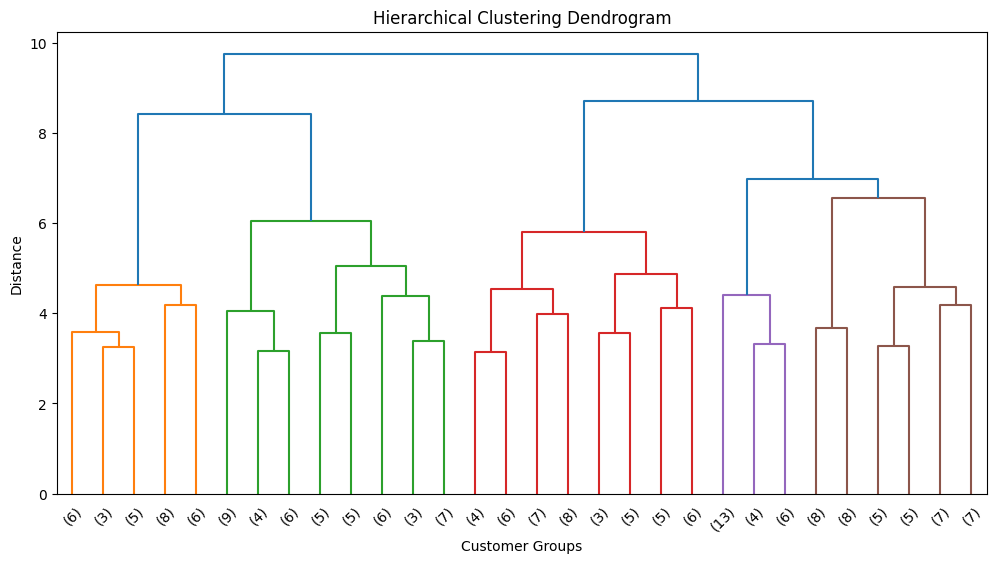

In [ ]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.show()

In [ ]:
hierarchical_results = []

for k in range(2, 8):

    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = hc.fit_predict(X_scaled)

    # Silhouette Score
    score = silhouette_score(
        X_scaled,
        labels
    )

    # Inertia-like SSE
    inertia = 0

    for cluster in np.unique(labels):

        cluster_points = X_scaled[labels == cluster]

        centroid = cluster_points.mean(axis=0)

        inertia += np.sum(
            (cluster_points - centroid) ** 2
        )

    hierarchical_results.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette_Score": score
    })

hierarchical_results = pd.DataFrame(
    hierarchical_results
)

hierarchical_results

,K,Inertia,Silhouette_Score
0,2,498.990895,0.092622
1,3,461.038922,0.087437
2,4,425.575551,0.105252
3,5,401.170458,0.106223
4,6,379.623879,0.110990
5,7,361.312924,0.125401


In [ ]:
best_k = hierarchical_results.loc[
    hierarchical_results["Silhouette_Score"].idxmax(),
    "K"
]

best_score = hierarchical_results["Silhouette_Score"].max()

print("Best K:", best_k)
print("Highest Silhouette Score:", best_score)

Best K: 7
Highest Silhouette Score: 0.12540120637732113


   K  Silhouette_Score
0  2          0.092622
1  3          0.087437
2  4          0.105252
3  5          0.106223
4  6          0.110990
5  7          0.125401


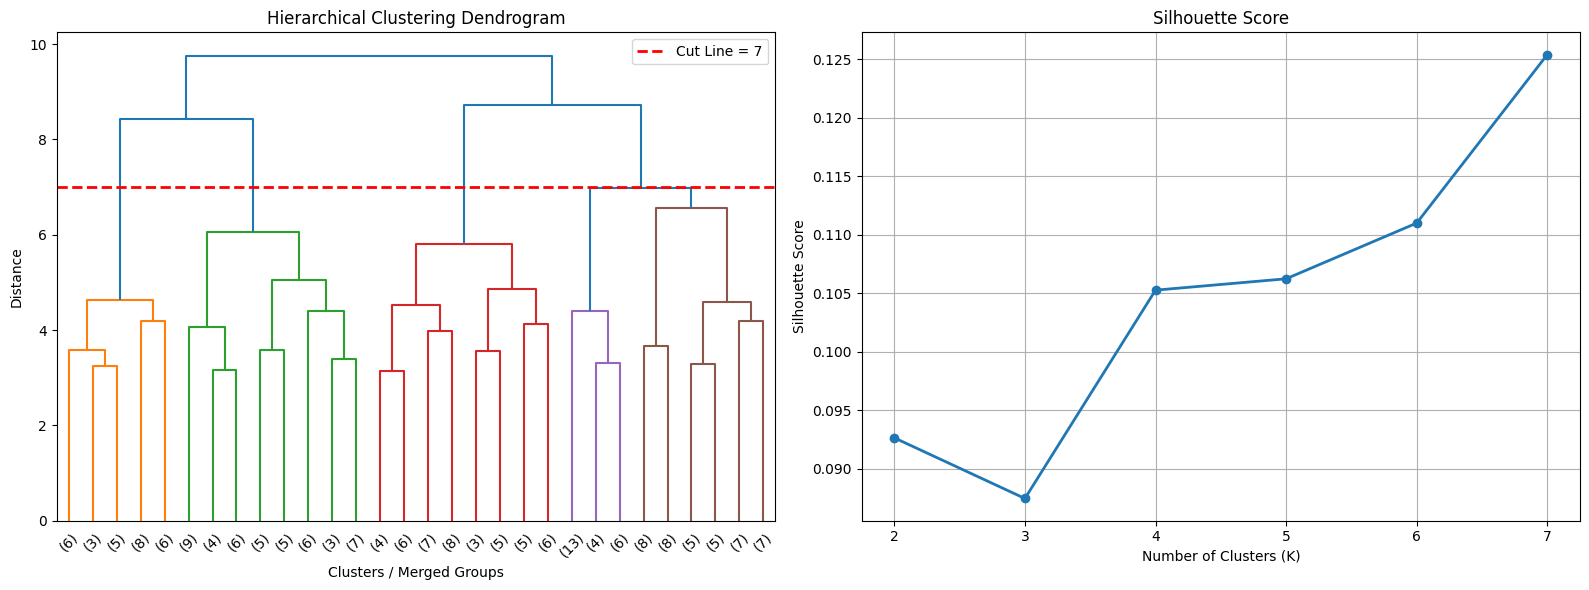

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score


Z = linkage(X_scaled, method="ward")



hierarchical_results = []

for k in range(2, 8):

    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = hc.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    hierarchical_results.append({
        "K": k,
        "Silhouette_Score": score
    })


hierarchical_results = pd.DataFrame(hierarchical_results)

print(hierarchical_results)




fig, ax = plt.subplots(1, 2, figsize=(16, 6))


dendrogram(
    Z,
    ax=ax[0],
    truncate_mode="lastp",
    p=30
)

cut_height = 7

ax[0].axhline(
    y=cut_height,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Cut Line = {cut_height}"
)

ax[0].set_title("Hierarchical Clustering Dendrogram")
ax[0].set_xlabel("Clusters / Merged Groups")
ax[0].set_ylabel("Distance")
ax[0].legend()


ax[1].plot(
    hierarchical_results["K"],
    hierarchical_results["Silhouette_Score"],
    marker="o",
    linewidth=2
)

ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_xticks(range(2, 8))
ax[1].grid(True)


plt.tight_layout()
plt.show()

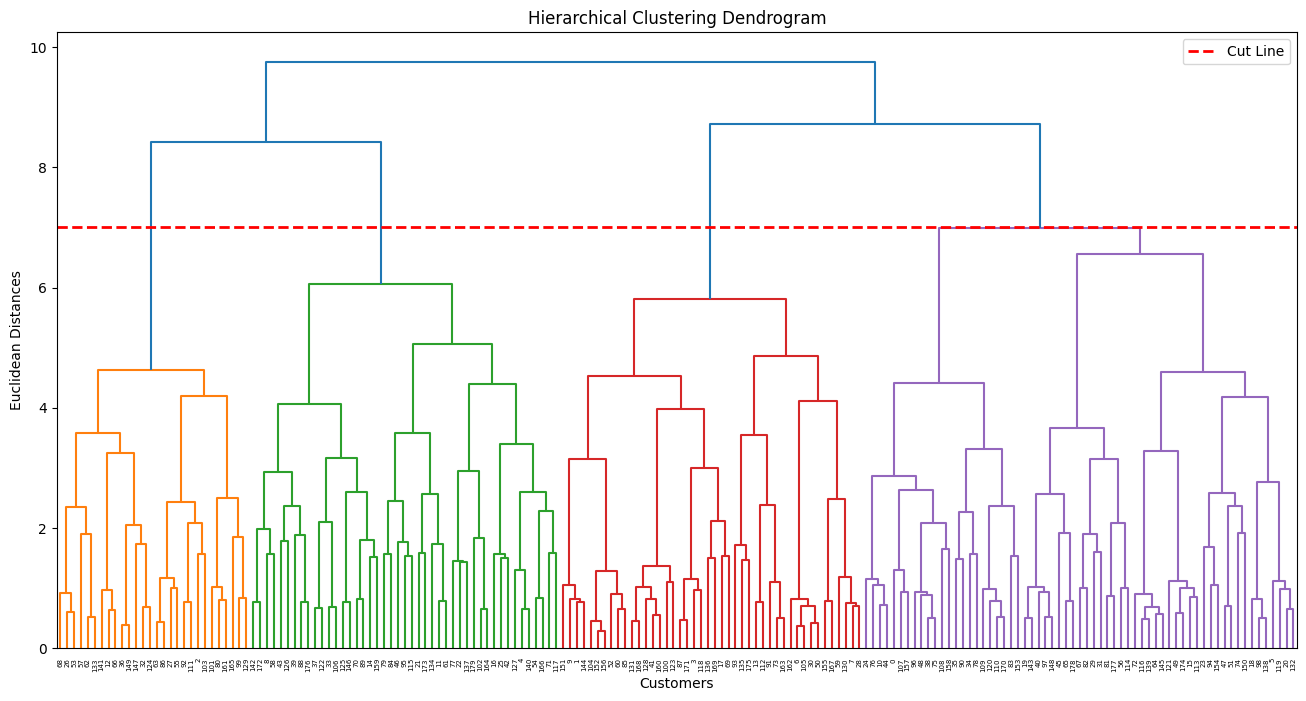

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(16, 8))

dendrogram(
    Z,
    color_threshold=7
)

# Choose a cut level that gives 4 clusters
cut_height = 7.0

plt.axhline(
    y=cut_height,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Cut Line"
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distances")
plt.legend()

plt.show()

In [ ]:
hc = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

df_cluster["Hierarchical_Cluster"] = hc.fit_predict(X_scaled)

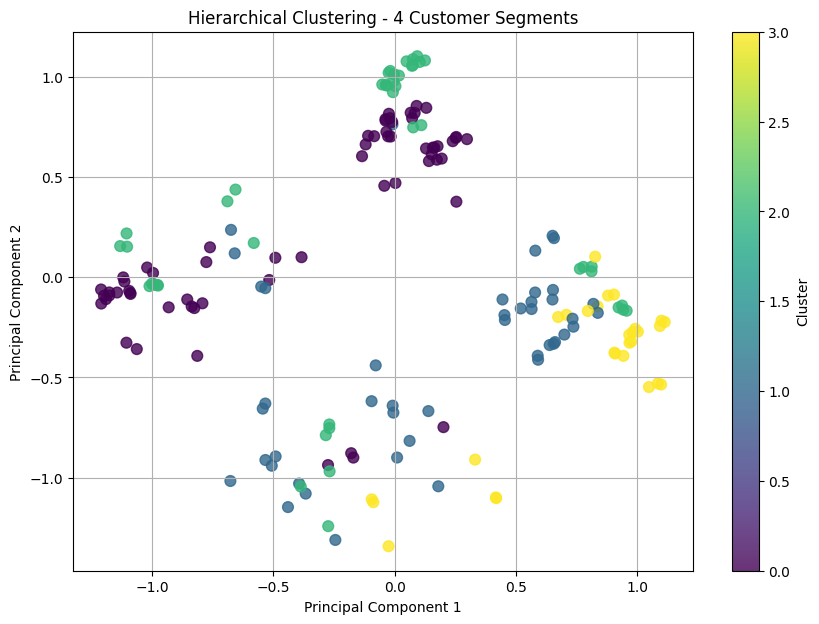

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_cluster["Hierarchical_Cluster"],
    cmap="viridis",
    s=60,
    alpha=0.8
)

plt.title("Hierarchical Clustering - 4 Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(True)
plt.show()

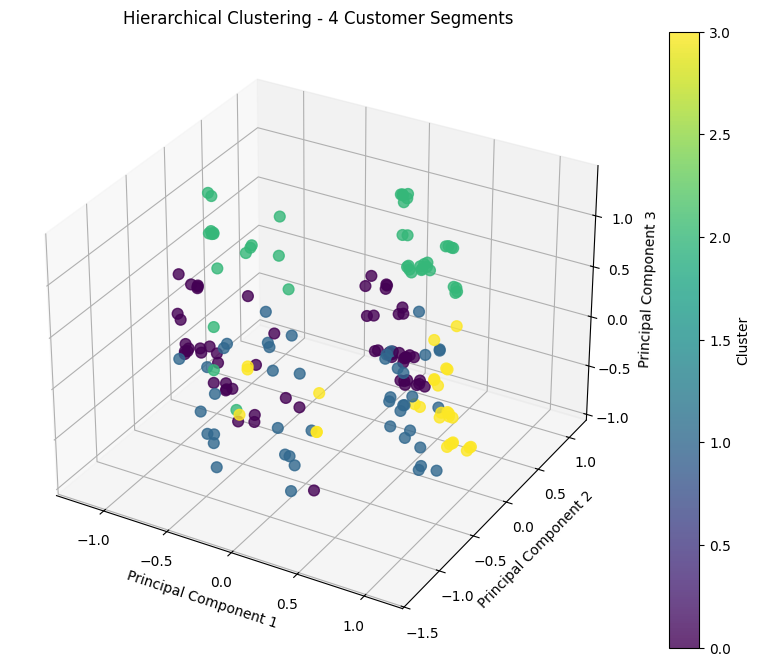

In [ ]:
pca = PCA(n_components=3)

X_pca_3d = pca.fit_transform(X_scaled)

# Create 3D plot
fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=df_cluster["Hierarchical_Cluster"],
    cmap="viridis",
    s=60,
    alpha=0.8
)

ax.set_title("Hierarchical Clustering - 4 Customer Segments")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.colorbar(
    scatter,
    ax=ax,
    label="Cluster"
)

plt.show()

In [ ]:
df_cluster["Hierarchical_Cluster"].value_counts().sort_index()

Hierarchical_Cluster
0    63
1    45
2    44
3    28
Name: count, dtype: int64

In [ ]:
hierarchical_profile = (
    df_cluster
    .groupby("Hierarchical_Cluster")[numeric_cols]
    .mean()
    .round(2)
)

hierarchical_profile

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Hierarchical_Cluster,,,,,,,
0,36.27,66330.16,37.98,74.57,3.11,17.99,5.68
1,35.20,66544.44,38.78,79.06,2.67,16.11,5.98
2,36.18,61863.64,41.39,72.47,3.48,20.99,6.07
3,38.39,65664.29,35.50,73.04,2.89,20.65,5.11


In [ ]:
hierarchical_names = {
    0: "Heavy-Usage Support Customers",
    1: "Moderate-Usage Customers",
    2: "Balanced Customers",
    3: "Premium High-Income Customers"
}

df_cluster["Hierarchical_Segment"] = (
    df_cluster["Hierarchical_Cluster"].map(hierarchical_names)
)

df_cluster[
    ["Hierarchical_Cluster", "Hierarchical_Segment"]
].head(20)

,Hierarchical_Cluster,Hierarchical_Segment
0,0,Heavy-Usage Support Customers
1,2,Balanced Customers
2,3,Premium High-Income Customers
3,2,Balanced Customers
4,1,Moderate-Usage Customers
5,0,Heavy-Usage Support Customers
6,2,Balanced Customers
7,2,Balanced Customers
8,1,Moderate-Usage Customers
9,2,Balanced Customers


## DBSCAN

In [ ]:
min_samples_values = [3, 4, 5, 6, 8, 10]

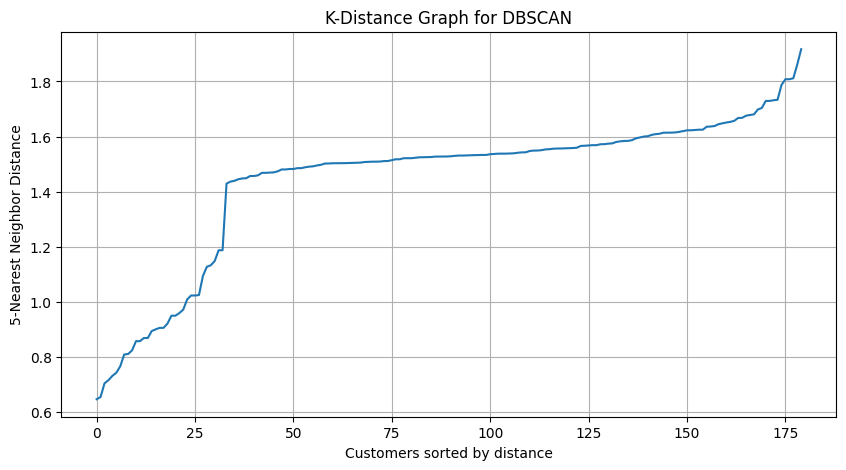

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Customers sorted by distance")
plt.ylabel(f"{min_samples}-Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")
plt.grid(True)

plt.show()

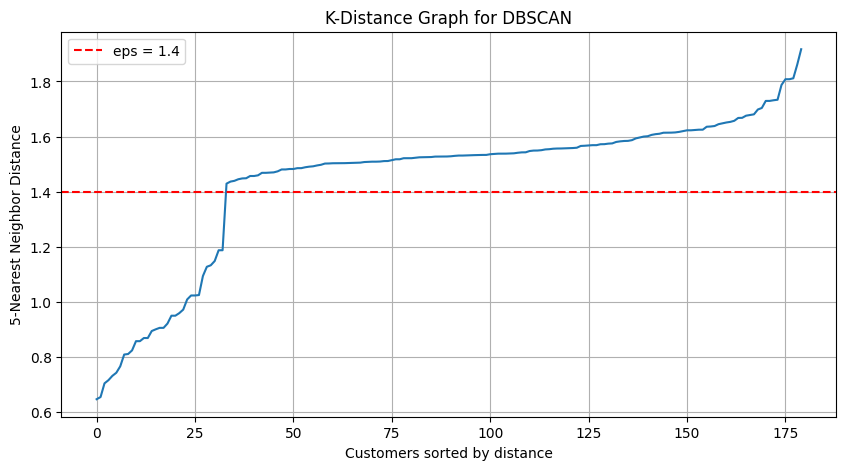

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.axhline(
    y=1.4,
    color="red",
    linestyle="--",
    label="eps = 1.4"
)

plt.xlabel("Customers sorted by distance")
plt.ylabel("5-Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
eps_values = [1.3, 1.35, 1.4, 1.45, 1.5]
min_samples_values = [3, 4, 5, 6, 8]

In [ ]:
results_dbscan = []

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        n_noise = np.sum(labels == -1)

        noise_percentage = (
            n_noise / len(labels)
        ) * 100

        mask = labels != -1

        if n_clusters >= 2:
            score = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )
        else:
            score = np.nan

        results_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "noise_percentage": round(noise_percentage, 2),
            "silhouette_score": round(score, 6)
            if not np.isnan(score) else np.nan
        })

dbscan_results = pd.DataFrame(results_dbscan)

dbscan_results

,eps,min_samples,clusters,noise_points,noise_percentage,silhouette_score
0,1.30,3,21,94,52.22,0.497599
1,1.30,4,14,115,63.89,0.516703
2,1.30,5,6,147,81.67,0.559343
3,1.30,6,2,167,92.78,0.494675
4,1.30,8,0,180,100.00,NaN
5,1.35,3,21,94,52.22,0.497599
6,1.35,4,14,115,63.89,0.516703
7,1.35,5,6,147,81.67,0.559343
8,1.35,6,2,167,92.78,0.494675
9,1.35,8,0,180,100.00,NaN


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(180, 22)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.50,
    min_samples=8
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df_cluster["DBSCAN_Cluster"] = dbscan_labels

In [ ]:
df_cluster["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1    129
 0     43
 1      8
Name: count, dtype: int64

In [ ]:
labels = dbscan.fit_predict(X)

In [ ]:
cluster_labels = dbscan.labels_
cluster_labels

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
import numpy as np

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

n_noise = np.sum(dbscan_labels == -1)

noise_percentage = (n_noise / len(dbscan_labels)) * 100

print("Number of Clusters:", n_clusters)
print("Noise Points:", n_noise)
print("Noise Percentage:", round(noise_percentage, 2), "%")

Number of Clusters: 2
Noise Points: 129
Noise Percentage: 71.67 %


In [ ]:
from sklearn.metrics import silhouette_score

mask = dbscan_labels != -1

if n_clusters >= 2:
    silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("Silhouette Score:", round(silhouette, 6))
else:
    print("Silhouette Score: Not applicable")

Silhouette Score: 0.218735


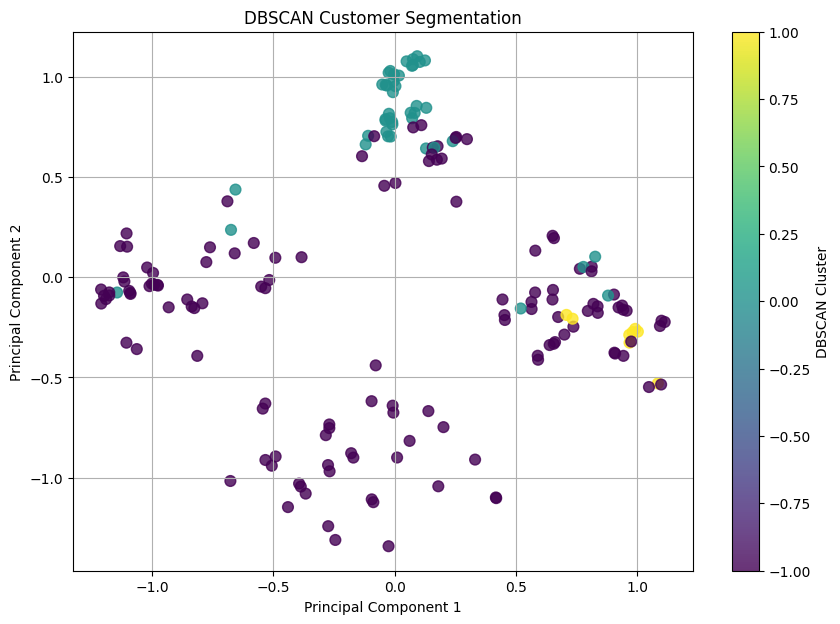

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=60,
    alpha=0.8
)

plt.title("DBSCAN Customer Segmentation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(
    scatter,
    label="DBSCAN Cluster"
)

plt.grid(True)
plt.show()

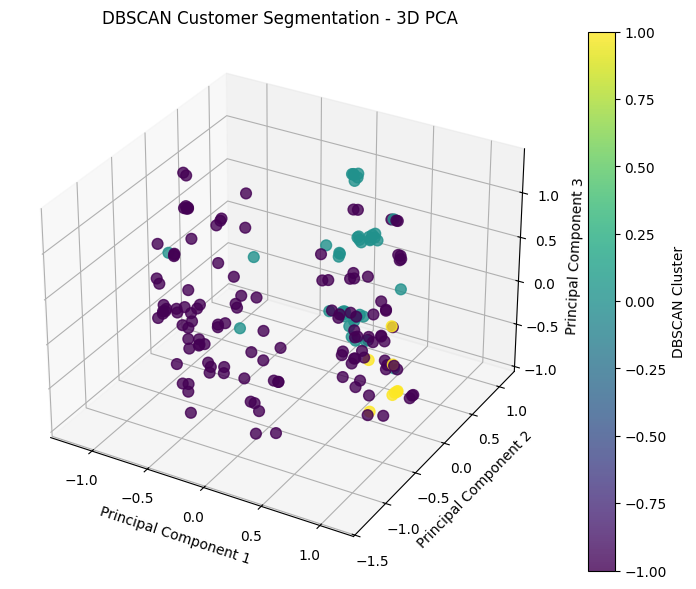

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot DBSCAN clusters
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=dbscan_labels,
    cmap="viridis",
    s=60,
    alpha=0.8
)

# Titles and labels
ax.set_title("DBSCAN Customer Segmentation - 3D PCA")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

# Colorbar
fig.colorbar(
    scatter,
    ax=ax,
    label="DBSCAN Cluster"
)

plt.show()

Purple (-1) = noise points

Teal (0) = DBSCAN Cluster 0

Yellow (1) = DBSCAN Cluster 1

You have 2 actual clusters
Most points are noise, which matches your 71.67% noise result.

In [ ]:
print("DBSCAN Results")
print("-------------------------")
print("eps:", 1.50)
print("min_samples:", 8)
print("Number of Clusters:", n_clusters)
print("Noise Points:", n_noise)
print("Noise Percentage:", round(noise_percentage, 2), "%")
print("Silhouette Score:", round(silhouette, 6))

DBSCAN Results
-------------------------
eps: 1.5
min_samples: 8
Number of Clusters: 2
Noise Points: 129
Noise Percentage: 71.67 %
Silhouette Score: 0.218735


In [ ]:
dbscan_numeric_profile = df_cluster.groupby(
    "DBSCAN_Cluster"
)[numeric_cols].mean().round(2)

dbscan_numeric_profile

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
DBSCAN_Cluster,,,,,,,
-1,36.47,66795.35,39.32,76.45,3.02,18.50,5.57
0,36.21,60067.44,36.67,69.57,3.16,18.54,6.37
1,34.25,66800.00,38.00,79.50,3.00,22.09,5.62


In [ ]:
pd.crosstab(
    df_cluster["DBSCAN_Cluster"],
    df_cluster["Plan_Type"],
    normalize="index"
).mul(100).round(2)

Plan_Type,Basic,Premium,Standard
DBSCAN_Cluster,,,
-1,28.68,28.68,42.64
0,6.98,2.33,90.70
1,87.50,12.50,0.00


In [ ]:
pd.crosstab(
    df_cluster["DBSCAN_Cluster"],
    df_cluster["Contract_Type"],
    normalize="index"
).mul(100).round(2)

Contract_Type,1 Year,2 Year,Monthly
DBSCAN_Cluster,,,
-1,39.53,17.05,43.41
0,2.33,4.65,93.02
1,0.00,0.00,100.00


In [ ]:
pd.crosstab(
    df_cluster["DBSCAN_Cluster"],
    df_cluster["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
DBSCAN_Cluster,,
-1,47.29,52.71
0,53.49,46.51
1,25.00,75.00


In [ ]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Number of clusters:", n_clusters)
print("Number of noise points:", list(dbscan_labels).count(-1))

Number of clusters: 2
Number of noise points: 129


In [ ]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.21873541441185992


## GMM

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
gmm_results = []

for k in range(2, 11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = gmm.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    gmm_results.append({
        "K": k,
        "Silhouette_Score": silhouette,
        "BIC": gmm.bic(X_scaled),
        "AIC": gmm.aic(X_scaled)
    })

gmm_results = pd.DataFrame(gmm_results)

gmm_results

,K,Silhouette_Score,BIC,AIC
0,2,0.126048,-8184.100593,-9943.419817
1,3,0.117518,-8236.742050,-10877.317366
2,4,0.141246,-8914.394175,-12436.225582
3,5,0.126690,-8637.599805,-13040.687303
4,6,0.126859,-8371.482474,-13655.826062
5,7,0.114036,-7549.968013,-13715.567692
6,8,0.097889,-5563.638602,-12610.494372
7,9,0.121656,-4465.957503,-12394.069363
8,10,0.123080,-4013.765702,-12823.133654


## Compare

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

comparison = []


labels_kmeans = df_cluster["Cluster"].values

comparison.append({
    "Algorithm": "K-Means",
    "Clusters": len(np.unique(labels_kmeans)),
    "Noise_%": 0,
    "Silhouette_Score": silhouette_score(
        X_scaled,
        labels_kmeans
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled,
        labels_kmeans
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled,
        labels_kmeans
    )
})



labels_hierarchical = df_cluster["Hierarchical_Cluster"].values

comparison.append({
    "Algorithm": "Hierarchical",
    "Clusters": len(np.unique(labels_hierarchical)),
    "Noise_%": 0,
    "Silhouette_Score": silhouette_score(
        X_scaled,
        labels_hierarchical
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled,
        labels_hierarchical
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled,
        labels_hierarchical
    )
})



labels_dbscan = df_cluster["DBSCAN_Cluster"].values

mask = labels_dbscan != -1

n_clusters_dbscan = len(
    set(labels_dbscan) - {-1}
)

noise_percentage = (
    np.sum(labels_dbscan == -1)
    / len(labels_dbscan)
) * 100

comparison.append({
    "Algorithm": "DBSCAN",
    "Clusters": n_clusters_dbscan,
    "Noise_%": noise_percentage,
    "Silhouette_Score": silhouette_score(
        X_scaled[mask],
        labels_dbscan[mask]
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled[mask],
        labels_dbscan[mask]
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled[mask],
        labels_dbscan[mask]
    )
})



comparison_df = pd.DataFrame(comparison)

comparison_df.round(4)

,Algorithm,Clusters,Noise_%,Silhouette_Score,Calinski_Harabasz,Davies_Bouldin
0,K-Means,4,0.0000,0.1412,22.9660,2.1505
1,Hierarchical,4,0.0000,0.1053,16.6850,2.4317
2,DBSCAN,2,71.6667,0.2187,10.4669,1.3844


In [ ]:
comparison_df.style.format({
    "Silhouette_Score": "{:.6f}",
    "Noise_%": "{:.2f}",
    "Calinski_Harabasz": "{:.2f}",
    "Davies_Bouldin": "{:.4f}"
})

,Algorithm,Clusters,Noise_%,Silhouette_Score,Calinski_Harabasz,Davies_Bouldin
0,K-Means,4,0.00,0.141246,22.97,2.1505
1,Hierarchical,4,0.00,0.105252,16.69,2.4317
2,DBSCAN,2,71.67,0.218735,10.47,1.3844


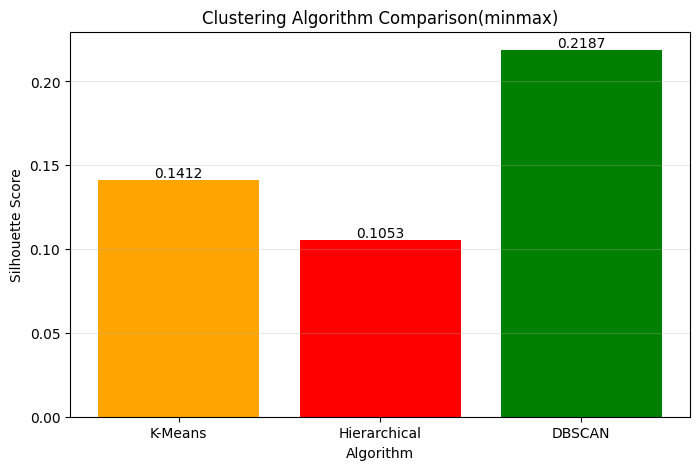

In [ ]:
plt.figure(figsize=(8, 5))

colors = ["orange","red","green"]

bars = plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Silhouette_Score"],
    color=colors
)

plt.title("Clustering Algorithm Comparison(minmax)")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

In [ ]:
!pip install plotly ipywidgets


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
algorithm_dropdown = widgets.Dropdown(
    options=[
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    value="K-Means",
    description="Algorithm:"
)

output = widgets.Output()


def create_dashboard(algorithm):

    with output:
        clear_output(wait=True)

        
        if algorithm == "K-Means":
            cluster_col = "Cluster"

        elif algorithm == "Hierarchical":
            cluster_col = "Hierarchical_Cluster"

        else:
            cluster_col = "DBSCAN_Cluster"

        data = df_cluster.copy()

    
        cluster_counts = (
            data[cluster_col]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        cluster_counts.columns = [
            "Cluster",
            "Customer_Count"
        ]

      

        fig1 = px.bar(
            cluster_counts,
            x="Cluster",
            y="Customer_Count",
            title=f"{algorithm} - Customer Distribution"
        )

        fig1.show()

    

        numeric_cols = [
            "Age",
            "Annual_Income",
            "Tenure_Months",
            "Monthly_Charges",
            "Support_Calls_Last_3M",
            "Data_Usage_GB",
            "Satisfaction_Score"
        ]

        profile = (
            data.groupby(cluster_col)[numeric_cols]
            .mean()
            .round(2)
        )

        display(profile)


        churn = pd.crosstab(
            data[cluster_col],
            data["Churn"],
            normalize="index"
        ).mul(100).round(2)

        display(churn)

    
        fig2 = px.scatter(
            data,
            x="Data_Usage_GB",
            y="Monthly_Charges",
            color=cluster_col,
            hover_data=[
                "Customer_ID",
                "Annual_Income",
                "Satisfaction_Score",
                "Churn"
            ],
            title=f"{algorithm} - Data Usage vs Monthly Charges"
        )

        fig2.show()


widgets.interactive(
    create_dashboard,
    algorithm=algorithm_dropdown
)

display(algorithm_dropdown)
display(output)

Dropdown(description='Algorithm:', options=('K-Means', 'Hierarchical', 'DBSCAN'), value='K-Means')

Output()